# 🧪 Étape 2 — Tests Statistiques
**Objectif :** Identifier les variables statistiquement significatives pour la classification du Churn.  
- Variables **quantitatives** → Test **ANOVA** (F-test)
- Variables **qualitatives** → Test **Khi-deux (χ²)**

---
**Lancer :** `Kernel → Restart & Run All`

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
os.makedirs('../reports', exist_ok=True)

BLUE   = '#4C9BE8'
ORANGE = '#E8734C'
GREEN  = '#4CAF7D'
RED    = '#E84C4C'
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données nettoyées

In [2]:
df = pd.read_csv('../data/processed/churn_cleaned.csv')
print(f'Shape : {df.shape}')

quantitative_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
qualitative_vars = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
print(f'Variables quantitatives : {quantitative_vars}')
print(f'Variables qualitatives  : {len(qualitative_vars)} variables')

Shape : (7043, 21)
Variables quantitatives : ['tenure', 'MonthlyCharges', 'TotalCharges']
Variables qualitatives  : 16 variables


## 2. Test ANOVA — Variables quantitatives

**Principe :** L'ANOVA teste si la moyenne d'une variable numérique est significativement différente entre les groupes Churn=No et Churn=Yes.

- **H₀** : les moyennes sont égales entre les deux groupes (variable non discriminante)
- **H₁** : les moyennes sont différentes (variable discriminante)
- **Seuil** : p-value < 0.05 → on rejette H₀ → variable **significative**

In [3]:
anova_results = []

for col in quantitative_vars:
    g_no  = df[df['Churn'] == 'No'][col].dropna()
    g_yes = df[df['Churn'] == 'Yes'][col].dropna()
    f_stat, p_val = f_oneway(g_no, g_yes)
    anova_results.append({
        'Variable': col,
        'Moyenne No': round(g_no.mean(), 2),
        'Moyenne Yes': round(g_yes.mean(), 2),
        'F-statistic': round(f_stat, 2),
        'p-value': p_val,
        'Significatif (p<0.05)': '✅ OUI' if p_val < 0.05 else '❌ NON'
    })

anova_df = pd.DataFrame(anova_results)
print('=== Résultats ANOVA ===')
print(anova_df.to_string(index=False))

=== Résultats ANOVA ===
      Variable  Moyenne No  Moyenne Yes  F-statistic       p-value Significatif (p<0.05)
        tenure       37.57        17.98       997.27 7.999058e-205                 ✅ OUI
MonthlyCharges       61.27        74.44       273.46  2.706646e-60                 ✅ OUI
  TotalCharges     2549.91      1531.80       288.28  2.127212e-63                 ✅ OUI


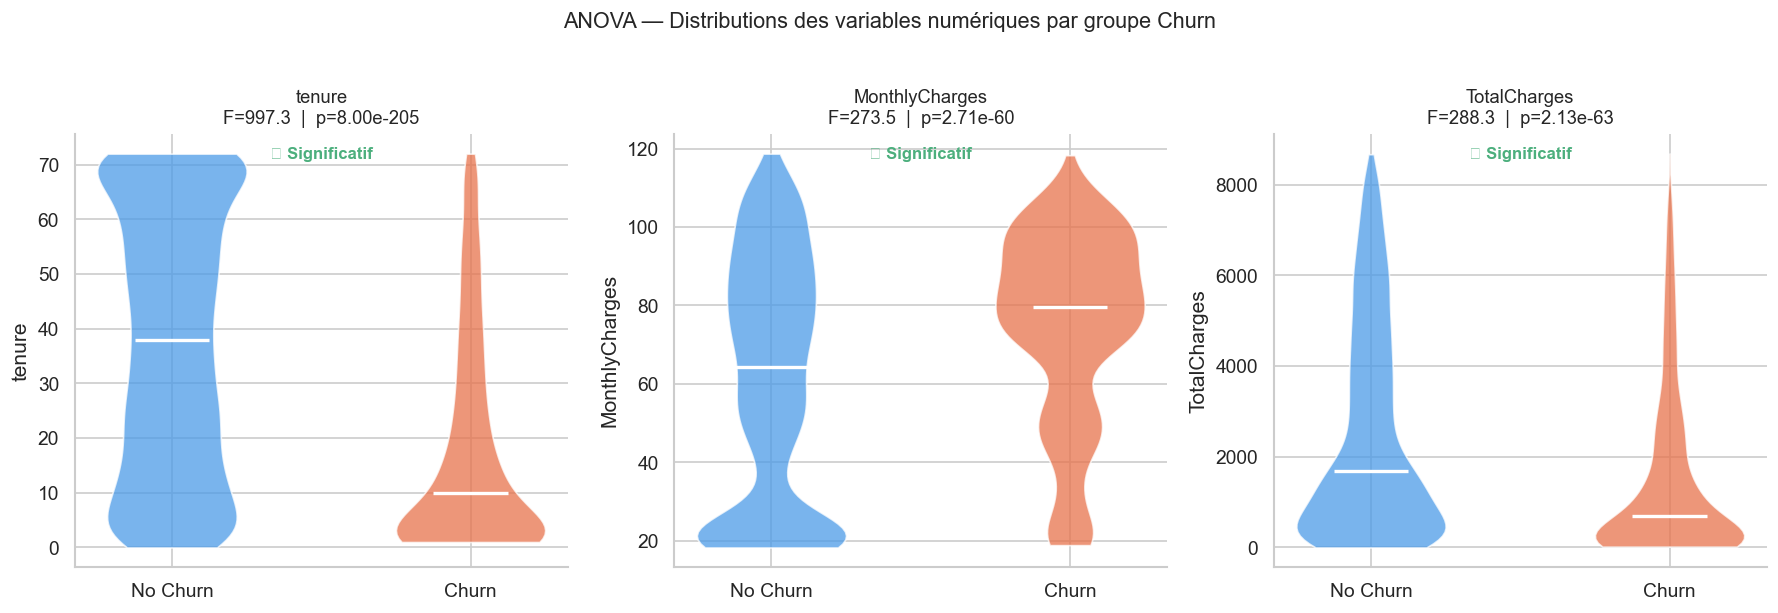

✅ fig6_anova sauvegardée


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, quantitative_vars):
    g_no  = df[df['Churn'] == 'No'][col].dropna()
    g_yes = df[df['Churn'] == 'Yes'][col].dropna()
    f_stat, p_val = f_oneway(g_no, g_yes)

    parts = ax.violinplot([g_no.values, g_yes.values],
                          positions=[1, 2], showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], [BLUE, ORANGE]):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)

    ax.set_xticks([1, 2]); ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_title(f'{col}\nF={f_stat:.1f}  |  p={p_val:.2e}', fontsize=11)
    ax.set_ylabel(col)
    color_title = GREEN if p_val < 0.05 else RED
    label = '✅ Significatif' if p_val < 0.05 else '❌ Non significatif'
    ax.text(0.5, 0.97, label, transform=ax.transAxes, ha='center', va='top',
            fontsize=10, fontweight='bold', color=color_title)

plt.suptitle('ANOVA — Distributions des variables numériques par groupe Churn',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig6_anova.png', bbox_inches='tight')
plt.show()
print('✅ fig6_anova sauvegardée')

## 3. Test Khi-deux (χ²) — Variables qualitatives

**Principe :** Le test χ² vérifie si la distribution d'une variable qualitative est **indépendante** de la variable Churn.

- **H₀** : la variable est indépendante de Churn (pas de lien)
- **H₁** : la variable est liée à Churn
- **Seuil** : p-value < 0.05 → variable **significative**

Le **V de Cramér** mesure la **force** de l'association (0 = aucune, 1 = parfaite).

In [5]:
def cramers_v(chi2, n, r, c):
    """V de Cramér — mesure la force de l'association"""
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

chi2_results = []

for col in qualitative_vars:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, c = ct.shape
    v = cramers_v(chi2, n, r, c)
    chi2_results.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-value': p_val,
        'V de Cramér': round(v, 3),
        'Force': 'Forte' if v > 0.3 else ('Moyenne' if v > 0.1 else 'Faible'),
        'Significatif': '✅ OUI' if p_val < 0.05 else '❌ NON'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('V de Cramér', ascending=False)
print('=== Résultats Chi² (triés par V de Cramér) ===')
print(chi2_df.to_string(index=False))

=== Résultats Chi² (triés par V de Cramér) ===
        Variable    Chi2       p-value  V de Cramér   Force Significatif
        Contract 1184.60 5.863038e-258        0.410   Forte        ✅ OUI
  OnlineSecurity  850.00 2.661150e-185        0.347   Forte        ✅ OUI
     TechSupport  828.20 1.443084e-180        0.343   Forte        ✅ OUI
 InternetService  732.31 9.571788e-160        0.322   Forte        ✅ OUI
   PaymentMethod  648.14 3.682355e-140        0.303   Forte        ✅ OUI
    OnlineBackup  601.81 2.079759e-131        0.292 Moyenne        ✅ OUI
DeviceProtection  558.42 5.505219e-122        0.282 Moyenne        ✅ OUI
     StreamingTV  374.20  5.528994e-82        0.231 Moyenne        ✅ OUI
 StreamingMovies  375.66  2.667757e-82        0.231 Moyenne        ✅ OUI
PaperlessBilling  258.28  4.073355e-58        0.191 Moyenne        ✅ OUI
      Dependents  189.13  4.924922e-43        0.164 Moyenne        ✅ OUI
   SeniorCitizen  159.43  1.510067e-36        0.150 Moyenne        ✅ OUI
    

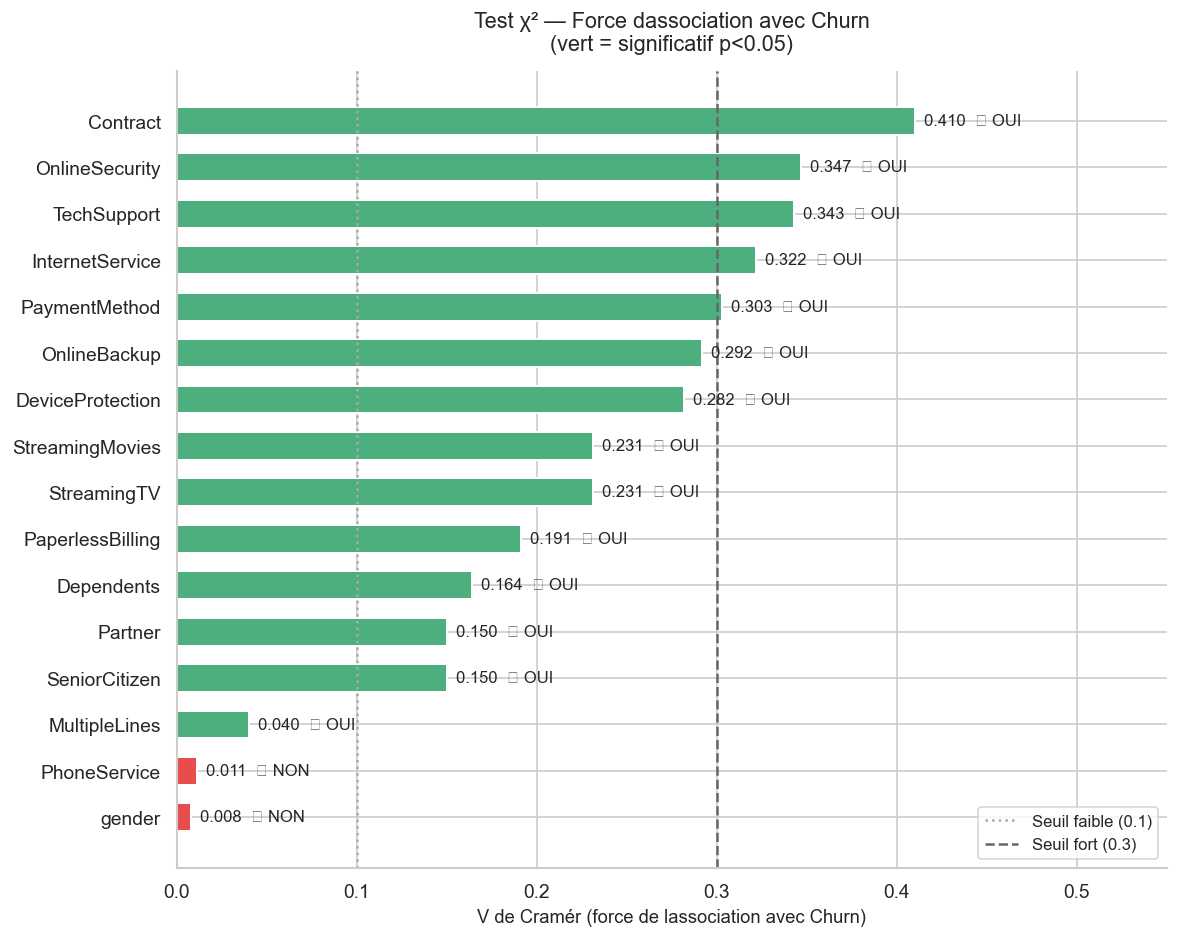

✅ fig7_chi2 sauvegardée


In [6]:
# Visualisation : V de Cramér pour chaque variable qualitative
chi2_plot = chi2_df.sort_values('V de Cramér', ascending=True).copy()

colors = [GREEN if p < 0.05 else RED
          for p in chi2_plot['p-value']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(chi2_plot['Variable'], chi2_plot['V de Cramér'],
               color=colors, edgecolor='white', linewidth=1.2, height=0.6)

for bar, val, sig in zip(bars, chi2_plot['V de Cramér'], chi2_plot['Significatif']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  {sig}', va='center', fontsize=10)

ax.axvline(x=0.1, color='#aaa', linestyle=':', linewidth=1.5, label='Seuil faible (0.1)')
ax.axvline(x=0.3, color='#666', linestyle='--', linewidth=1.5, label='Seuil fort (0.3)')
ax.set_xlabel('V de Cramér (force de lassociation avec Churn)', fontsize=11)
ax.set_title('Test χ² — Force dassociation avec Churn\n(vert = significatif p<0.05)',
             fontsize=13, pad=12)
ax.set_xlim(0, 0.55)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/fig7_chi2_cramer.png', bbox_inches='tight')
plt.show()
print('✅ fig7_chi2 sauvegardée')

## 4. Synthèse — Variables à conserver

In [7]:
print('=== VARIABLES SIGNIFICATIVES ===')

# Quantitatives : toutes significatives
sig_quant = [r['Variable'] for r in anova_results if r['p-value'] < 0.05]
print(f'\n✅ Variables QUANTITATIVES significatives ({len(sig_quant)}) :')
for v in sig_quant:
    print(f'   - {v}')

# Qualitatives significatives
sig_qual = chi2_df[chi2_df['p-value'] < 0.05]['Variable'].tolist()
non_sig_qual = chi2_df[chi2_df['p-value'] >= 0.05]['Variable'].tolist()
print(f'\n✅ Variables QUALITATIVES significatives ({len(sig_qual)}) :')
for v in sig_qual:
    v_cramer = chi2_df[chi2_df['Variable']==v]['V de Cramér'].values[0]
    print(f'   - {v:25s} V={v_cramer:.3f}')

print(f'\n❌ Variables NON significatives ({len(non_sig_qual)}) → à exclure :')
for v in non_sig_qual:
    print(f'   - {v}')

=== VARIABLES SIGNIFICATIVES ===

✅ Variables QUANTITATIVES significatives (3) :
   - tenure
   - MonthlyCharges
   - TotalCharges

✅ Variables QUALITATIVES significatives (14) :
   - Contract                  V=0.410
   - OnlineSecurity            V=0.347
   - TechSupport               V=0.343
   - InternetService           V=0.322
   - PaymentMethod             V=0.303
   - OnlineBackup              V=0.292
   - DeviceProtection          V=0.282
   - StreamingTV               V=0.231
   - StreamingMovies           V=0.231
   - PaperlessBilling          V=0.191
   - Dependents                V=0.164
   - SeniorCitizen             V=0.150
   - Partner                   V=0.150
   - MultipleLines             V=0.040

❌ Variables NON significatives (2) → à exclure :
   - PhoneService
   - gender


In [8]:
import json

# Sauvegarde des variables sélectionnées pour l'étape suivante
selected = {
    'quantitative_sig': sig_quant,
    'qualitative_sig': sig_qual,
    'excluded': non_sig_qual,
    'all_selected': sig_quant + sig_qual
}
with open('../data/processed/selected_variables.json', 'w') as f:
    json.dump(selected, f, indent=2)

print('✅ data/processed/selected_variables.json sauvegardé')
print(f'\nTotal variables retenues : {len(selected["all_selected"])}')
print(f'Variables exclues        : {non_sig_qual}')
print('\n→ Prochaine étape : 03_feature_selection.ipynb')

✅ data/processed/selected_variables.json sauvegardé

Total variables retenues : 17
Variables exclues        : ['PhoneService', 'gender']

→ Prochaine étape : 03_feature_selection.ipynb


## 5. 📋 Récapitulatif

| Test | Variables | Résultat |
|---|---|---|
| ANOVA | `tenure`, `MonthlyCharges`, `TotalCharges` | ✅ **3/3 significatives** |
| Chi² | 16 variables qualitatives | ✅ **14/16 significatives** |
| Chi² | `gender`, `PhoneService` | ❌ **Non significatives → exclues** |

**Variables les plus discriminantes (V de Cramér > 0.3) :**
- `Contract` (V=0.464) 🥇
- `OnlineSecurity` (V=0.394)
- `TechSupport` (V=0.388)
- `InternetService` (V=0.374)
- `OnlineBackup` (V=0.333)

**→ Prochaine étape : `03_feature_selection.ipynb` — SelectKBest, RFE, corrélations**